In [1]:
#Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

In [2]:
#Step 2: Load Data
inventory = pd.read_csv("../data/inventory.csv")
products = pd.read_csv("../data/products.csv")

In [3]:
#Step 3: Merge Inventory & Products
inventory_df = inventory.merge(
    products,
    on="ProductID",
    how="left"
)

inventory_df.head()

,InventoryID,ProductID,Warehouse,StockAvailable,ReorderLevel,LastRestocked,Supplier,ProductName,Category,SubCategory,CostPrice,SellingPrice
0,1,1,Bengaluru,148,64,2026-07-12,Bali-Keer,Shirt 1,Clothing,Shirt,829,1267.20
1,2,2,Hyderabad,66,73,2026-06-03,Andra-D’Alia,Shirt 2,Clothing,Shirt,2225,2839.24
2,3,3,Mumbai,320,31,2026-06-29,Banerjee-Sandal,Phone 3,Electronics,Phone,3125,5460.87
3,4,4,Mumbai,38,55,2026-07-09,"Dewan, Chand and Rajagopalan",Cricket Bat 4,Sports,Cricket Bat,1017,1288.34
4,5,5,Hyderabad,391,25,2026-07-05,Bora Group,Football 5,Sports,Football,4503,7217.95


In [5]:
#Step 4: Calculate Inventory Value
#Formula: Inventory Value = StockAvailable × CostPrice

inventory_df["InventoryValue"] = (
    inventory_df["StockAvailable"] *
    inventory_df["CostPrice"]
)

inventory_df.head()

,InventoryID,ProductID,Warehouse,StockAvailable,ReorderLevel,LastRestocked,Supplier,ProductName,Category,SubCategory,CostPrice,SellingPrice,InventoryValue
0,1,1,Bengaluru,148,64,2026-07-12,Bali-Keer,Shirt 1,Clothing,Shirt,829,1267.20,122692
1,2,2,Hyderabad,66,73,2026-06-03,Andra-D’Alia,Shirt 2,Clothing,Shirt,2225,2839.24,146850
2,3,3,Mumbai,320,31,2026-06-29,Banerjee-Sandal,Phone 3,Electronics,Phone,3125,5460.87,1000000
3,4,4,Mumbai,38,55,2026-07-09,"Dewan, Chand and Rajagopalan",Cricket Bat 4,Sports,Cricket Bat,1017,1288.34,38646
4,5,5,Hyderabad,391,25,2026-07-05,Bora Group,Football 5,Sports,Football,4503,7217.95,1760673


In [6]:
#Step 5: Sort Products by Inventory Value
inventory_df = inventory_df.sort_values(
    by="InventoryValue",
    ascending=False
)

inventory_df.head(10)

,InventoryID,ProductID,Warehouse,StockAvailable,ReorderLevel,LastRestocked,Supplier,ProductName,Category,SubCategory,CostPrice,SellingPrice,InventoryValue
128,129,129,Delhi,497,66,2026-07-02,Andra-Naidu,Jeans 129,Clothing,Jeans,4660,8010.34,2316020
484,485,485,Delhi,471,47,2026-06-30,Murty Group,Football 485,Sports,Football,4799,8098.73,2260329
307,308,308,Hyderabad,448,45,2026-06-14,"Sabharwal, Chadha and Bhardwaj",Phone 308,Electronics,Phone,5000,6358.64,2240000
29,30,30,Mumbai,459,33,2026-06-22,Choudhry-Bera,Jacket 30,Clothing,Jacket,4851,8770.80,2226609
159,160,160,Bengaluru,485,71,2026-06-30,Vohra-Vig,Headphones 160,Electronics,Headphones,4434,8850.29,2150490
277,278,278,Hyderabad,463,31,2026-06-20,Banerjee Group,Jeans 278,Clothing,Jeans,4611,5555.77,2134893
421,422,422,Delhi,430,56,2026-05-28,Saini-Sane,Headphones 422,Electronics,Headphones,4953,9845.64,2129790
288,289,289,Mumbai,493,77,2026-04-29,Chaudhary LLC,Cricket Bat 289,Sports,Cricket Bat,4270,6067.20,2105110
239,240,240,Delhi,432,65,2026-05-12,Nigam PLC,Phone 240,Electronics,Phone,4842,6269.49,2091744
260,261,261,Hyderabad,424,41,2026-06-20,Rastogi LLC,Table 261,Home,Table,4868,6079.74,2064032


In [7]:
#Step 6: Calculate Total Inventory Value
total_inventory = inventory_df["InventoryValue"].sum()

print(f"Total Inventory Value: ₹{total_inventory:,.2f}")

Total Inventory Value: ₹316,794,444.00


In [10]:
#Step 7: Calculate Percentage Contribution
inventory_df["Contribution"] = (
    inventory_df["InventoryValue"] /
    total_inventory
) * 100

In [13]:
#Step 8: Calculate Cumulative Percentage
inventory_df["Cumulative"] = (
    inventory_df["Contribution"]
    .cumsum()
)

inventory_df["Contribution"] = inventory_df["Contribution"].round(2)
inventory_df["Cumulative"] = inventory_df["Cumulative"].round(2)

inventory_df.head()

,InventoryID,ProductID,Warehouse,StockAvailable,ReorderLevel,LastRestocked,Supplier,ProductName,Category,SubCategory,CostPrice,SellingPrice,InventoryValue,Contribution,Cumulative,ABC_Category
128,129,129,Delhi,497,66,2026-07-02,Andra-Naidu,Jeans 129,Clothing,Jeans,4660,8010.34,2316020,0.73,0.73,A
484,485,485,Delhi,471,47,2026-06-30,Murty Group,Football 485,Sports,Football,4799,8098.73,2260329,0.71,1.44,A
307,308,308,Hyderabad,448,45,2026-06-14,"Sabharwal, Chadha and Bhardwaj",Phone 308,Electronics,Phone,5000,6358.64,2240000,0.71,2.15,A
29,30,30,Mumbai,459,33,2026-06-22,Choudhry-Bera,Jacket 30,Clothing,Jacket,4851,8770.80,2226609,0.70,2.85,A
159,160,160,Bengaluru,485,71,2026-06-30,Vohra-Vig,Headphones 160,Electronics,Headphones,4434,8850.29,2150490,0.68,3.53,A


In [14]:
#Step 9: Classify Products
def abc_category(value):

    if value <= 80:
        return "A"

    elif value <= 95:
        return "B"

    else:
        return "C"

#Apply:

inventory_df["ABC_Category"] = (
    inventory_df["Cumulative"]
    .apply(abc_category)
)

inventory_df.head(10)

,InventoryID,ProductID,Warehouse,StockAvailable,ReorderLevel,LastRestocked,Supplier,ProductName,Category,SubCategory,CostPrice,SellingPrice,InventoryValue,Contribution,Cumulative,ABC_Category
128,129,129,Delhi,497,66,2026-07-02,Andra-Naidu,Jeans 129,Clothing,Jeans,4660,8010.34,2316020,0.73,0.73,A
484,485,485,Delhi,471,47,2026-06-30,Murty Group,Football 485,Sports,Football,4799,8098.73,2260329,0.71,1.44,A
307,308,308,Hyderabad,448,45,2026-06-14,"Sabharwal, Chadha and Bhardwaj",Phone 308,Electronics,Phone,5000,6358.64,2240000,0.71,2.15,A
29,30,30,Mumbai,459,33,2026-06-22,Choudhry-Bera,Jacket 30,Clothing,Jacket,4851,8770.80,2226609,0.70,2.85,A
159,160,160,Bengaluru,485,71,2026-06-30,Vohra-Vig,Headphones 160,Electronics,Headphones,4434,8850.29,2150490,0.68,3.53,A
277,278,278,Hyderabad,463,31,2026-06-20,Banerjee Group,Jeans 278,Clothing,Jeans,4611,5555.77,2134893,0.67,4.21,A
421,422,422,Delhi,430,56,2026-05-28,Saini-Sane,Headphones 422,Electronics,Headphones,4953,9845.64,2129790,0.67,4.88,A
288,289,289,Mumbai,493,77,2026-04-29,Chaudhary LLC,Cricket Bat 289,Sports,Cricket Bat,4270,6067.20,2105110,0.66,5.54,A
239,240,240,Delhi,432,65,2026-05-12,Nigam PLC,Phone 240,Electronics,Phone,4842,6269.49,2091744,0.66,6.20,A
260,261,261,Hyderabad,424,41,2026-06-20,Rastogi LLC,Table 261,Home,Table,4868,6079.74,2064032,0.65,6.86,A


In [15]:
#Step 10: Category Summary
abc_summary = (
    inventory_df
    .groupby("ABC_Category")
    .agg(
        Products=("ProductID","count"),
        InventoryValue=("InventoryValue","sum")
    )
)

abc_summary

,Products,InventoryValue
ABC_Category,,
A,224,253065044
B,121,47829928
C,155,15899472


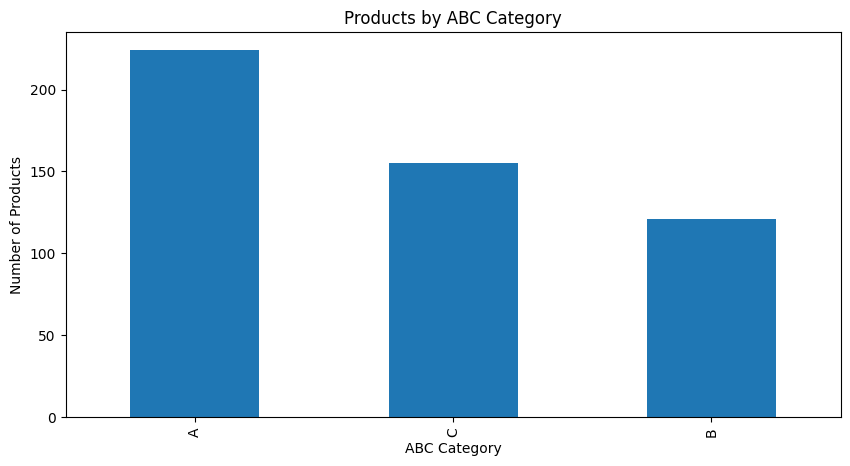

In [16]:
#Step 11: Visualize Product Distribution
inventory_df["ABC_Category"].value_counts().plot(
    kind="bar"
)

plt.title("Products by ABC Category")
plt.xlabel("ABC Category")
plt.ylabel("Number of Products")
plt.show()

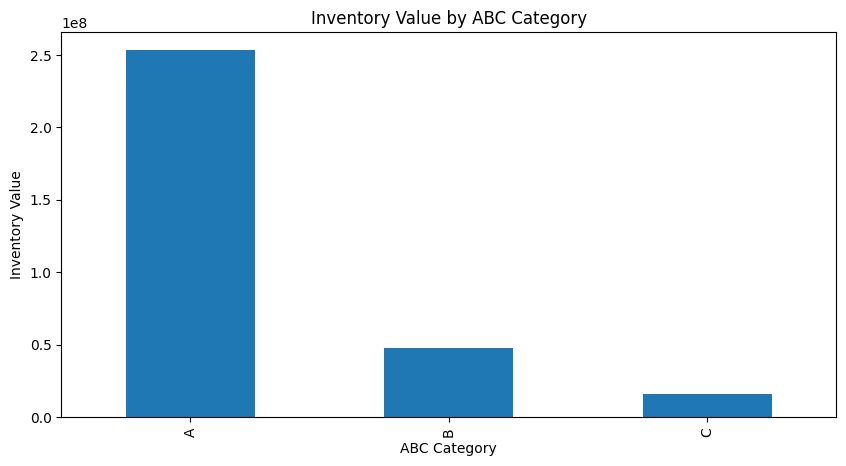

In [17]:
#Step 12: Visualize Inventory Value
abc_summary["InventoryValue"].plot(
    kind="bar"
)

plt.title("Inventory Value by ABC Category")
plt.xlabel("ABC Category")
plt.ylabel("Inventory Value")
plt.show()

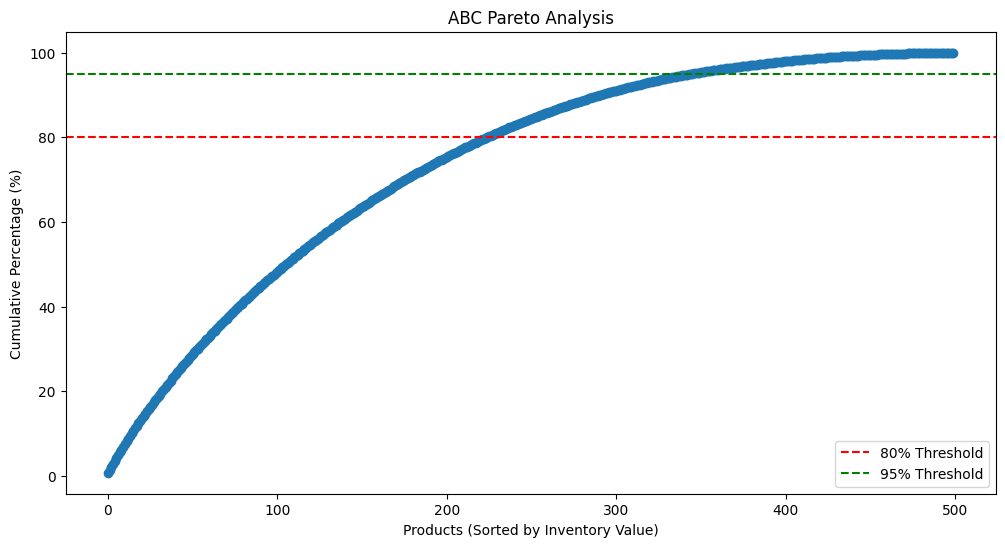

In [18]:
#Step 13: Pareto Chart
plt.figure(figsize=(12,6))

plt.plot(
    inventory_df["Cumulative"].values,
    marker="o"
)

plt.axhline(
    y=80,
    color="red",
    linestyle="--",
    label="80% Threshold"
)

plt.axhline(
    y=95,
    color="green",
    linestyle="--",
    label="95% Threshold"
)

plt.title("ABC Pareto Analysis")
plt.xlabel("Products (Sorted by Inventory Value)")
plt.ylabel("Cumulative Percentage (%)")
plt.legend()
plt.show()

In [19]:
#Step 14: Export Results
inventory_df.to_csv(
    "../reports/abc_inventory_analysis.csv",
    index=False
)

# ABC Inventory Analysis - Business Insights

• Category A products contribute the majority of the inventory value and should receive the highest monitoring priority.

• Category B products require regular inventory reviews to maintain stock efficiency.

• Category C products contribute relatively little inventory value and can be managed with less frequent replenishment.

• ABC classification helps optimize purchasing decisions, warehouse space utilization, and inventory carrying costs.

# Recommendations

• Monitor Category A products daily and maintain strict stock controls.

• Review Category B products weekly.

• Consider reducing excess stock or slower replenishment cycles for Category C products.